<div align="center" >
    <br /><br />
    <h1>Universidad de Sevilla</h1>
    <h2>Escuela Técnica Superior de Ingeniería Informática</h2>
    <h3>Grado en Ingeniería del Software</h3>
    <img src="images/logo_us.png" alt="Logo Universidad de Sevilla" width="250" />
    <br />
    <hr />
    <br />
    <h1>Construcción de modelos base de clasificación</h1>
    <h2>Validación y evaluación sobre características manuales</h2>
    <br />
    <hr />
    <br />
    <p><strong>Asignatura:</strong> Inteligencia Artificial</p>
    <p><strong>Grupo:</strong> Aprendizaje Automático Relacional - G5</p>
    <p><strong>Curso Académico:</strong> 2025/2026</p>
</div>

<br /><br /><br /><br />

<div align="right" >
    <p><strong>Autores:</strong><br />
    Juan Antonio Fernández Ruiz<br />
    Eulogio Reyes Díaz<br />
</div>

<div align="right" >
    <p><strong>Fecha:</strong> 7 de Junio de 2026</p>
</div>

<br /><br />

## Indice de contenidos

- [0. Introduccion y objetivo](#0-introduccion-y-objetivo)
- [1. Enfoque de implementacion](#1-enfoque-de-implementacion)
- [2. Configuracion y carga de datos](#2-configuración-y-carga-de-datos)
- [3. Preparacion de entrenamiento y prueba](#3-preparación-de-entrenamiento-y-prueba)
- [4. Modelos base y espacios de busqueda](#4-modelos-base-y-espacios-de-búsqueda)
- [5. Validacion cruzada y ajuste de hiperparametros](#5-validación-cruzada-y-ajuste-de-hiperparámetros)
- [6. Evaluacion final en el conjunto de prueba](#6-evaluación-final-en-el-conjunto-de-prueba)
- [7. Seleccion del mejor modelo y analisis detallado](#7-selección-del-mejor-modelo-y-análisis-detallado)
- [8. Persistencia de artefactos (trazabilidad)](#8-persistencia-de-artefactos-trazabilidad)
- [9. Conclusiones y siguientes pasos](#9-conclusiones-y-siguientes-pasos)

# Construcción de modelos base

## 0. Introducción y objetivo

- 1.  **La partición de los datos:** Vamos a dividir el conjunto de ejemplos en subconjuntos de entrenamiento y prueba. Para ello, aplicaremos la técnica de validación por retención (*holdout validation*).
- 2.  **La inicialización de los algoritmos:** El trabajo exige construir al menos tres modelos de clasificación estándar. Importaremos y configuraremos los métodos propuestos en la teoría, tales como **k-vecinos más cercanos (kNN)**, **árboles de clasificación**, modelos probabilísticos como **Naive Bayes**, o **redes neuronales** multicapa.
- 3.  **La configuración de la búsqueda de hiper-parámetros:** Vamos a dejar preparada la estructura de código para realizar una **búsqueda en rejilla** (*grid search*) que evalúe diferentes combinaciones de hiper-parámetros para cada modelo.
- 4.  **Las métricas de rendimiento:** Programar el código para extraer la matriz de confusión y calcular medidas como la tasa de acierto (*accuracy*) o la tasa de error, necesarias para estimar la capacidad de generalización.

## 1. Enfoque de implementacion

En esta sección vamos a construir modelos base de clasificación para Cora usando Scikit-learn, siguiendo una metodología reproducible:

1. Preparar los datos de entrada y salida.
2. Separar entrenamiento y prueba con estratificación.
3. Ajustar hiperparámetros con validación cruzada.
4. Evaluar en test con métricas globales y por clase.

In [1]:
import warnings
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 120)

## 2. Configuración y carga de datos

Primero buscamos un CSV consolidado (opción A). Si no existe, construimos el dataset combinado a partir de:

- Atributos nativos de cora.content.
- Estructura relacional en cora.cites.

Este enfoque permite ejecutar el notebook de forma autónoma sin depender de pasos manuales previos.

In [ ]:
%load_ext autoreload
%autoreload 2

from data_loader import cargar_datos_cora
from sklearn.preprocessing import LabelEncoder

# Carga limpia 
base_dir = Path.cwd().resolve()
if base_dir.name == "notebooks":
    base_dir = base_dir.parent

ruta_csv = base_dir / "data" / "cora_features_completas.csv"
X, y = cargar_datos_cora(ruta_csv)
fuente_datos = f"CSV consolidado: {ruta_csv.name}"

# Codificamos las etiquetas a números AHORA
le = LabelEncoder()
y_numerica = le.fit_transform(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y_numerica.shape}")
print("Mapeo de clases:", dict(zip(le.classes_, le.transform(le.classes_))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
X shape: (2708, 1437)
y shape: (2708,)
Mapeo de clases: {'Case_Based': 0, 'Genetic_Algorithms': 1, 'Neural_Networks': 2, 'Probabilistic_Methods': 3, 'Reinforcement_Learning': 4, 'Rule_Learning': 5, 'Theory': 6}


## 3. Preparación de entrenamiento y prueba

Dividimos el dataset en train/test con estratificación para conservar la proporción de clases en ambos subconjuntos. Esto evita sesgos al evaluar modelos multiclase con clases desbalanceadas.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_numerica, 
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_numerica
)

print(f"Train shape: {X_train.shape}")
print("\nDistribución de clases en train (top 7):")
print(pd.Series(y_train).value_counts(normalize=True).head(7))
print("\nDistribución de clases en test (top 7):")
print(pd.Series(y_test).value_counts(normalize=True).head(7))

Train shape: (2166, 1437)

Distribución de clases en train (top 7):
2    0.301939
3    0.157433
1    0.154201
6    0.129732
0    0.109880
4    0.080332
5    0.066482
Name: proportion, dtype: float64

Distribución de clases en test (top 7):
2    0.302583
3    0.156827
1    0.154982
6    0.129151
0    0.110701
4    0.079336
5    0.066421
Name: proportion, dtype: float64


## 4. Modelos base y espacios de búsqueda

Entrenaremos cuatro modelos base:

- kNN
- Arbol de Decision
- Naive Bayes Gaussiano
- MLP (red neuronal multicapa)

Para cada uno definimos un grid razonable de hiperparámetros y usaremos validación cruzada para seleccionar la mejor configuración según F1 macro.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.neural_network import MLPClassifier

# =====================================================================
# 1. DEFINICIÓN DEL PREPROCESADOR (ColumnTransformer)
# =====================================================================
# Agrupamos las características por su naturaleza matemática
text_features = [col for col in X_train.columns if col.startswith("word_")]
graph_continuous_features = ["centralidad_grado", "centralidad_betweenness", "coeficiente_clustering"]
categorical_features = ["comunidad_louvain"]

# Aplicamos la transformación adecuada a cada grupo
preprocesador = ColumnTransformer(
    transformers=[
        ("escalador_grafos", RobustScaler(), graph_continuous_features),
        ("encoder_comunidad", OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ("texto_binario", "passthrough", text_features)
    ]
)

# =====================================================================
# 2. DEFINICIÓN DE PIPELINES (Modelos Base)
# =====================================================================
# Integramos el preprocesador dinámico dentro de cada algoritmo
modelos = {
    "kNN": Pipeline([
        ("preprocesamiento", preprocesador), 
        ("clf", KNeighborsClassifier())
    ]),
    "ArbolDecision": Pipeline([
        ("preprocesamiento", preprocesador), 
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("preprocesamiento", preprocesador), 
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
    ]),
    "NaiveBayes_Bernoulli": Pipeline([
        ("preprocesamiento", preprocesador), 
        ("clf", BernoulliNB())
    ]),
    "MLP": Pipeline([
        ("preprocesamiento", preprocesador), 
        ("clf", MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE))
    ]),
}

# =====================================================================
# 3. ESPACIOS DE BÚSQUEDA DE HIPERPARÁMETROS (Grids)
# =====================================================================
grids = {
    "kNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2], 
    },
    "ArbolDecision": {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5],
    },
    "RandomForest": {
        "clf__n_estimators": [50, 100],
        "clf__max_depth": [None, 20],
    },
    "NaiveBayes_Bernoulli": {
        "clf__alpha": [0.1, 0.5, 1.0], 
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(64,), (128,)],
        "clf__alpha": [1e-4, 1e-3], 
        "clf__learning_rate_init": [1e-3, 1e-2],
    },
}

print(f"✅ Preprocesador y {len(modelos)} modelos base definidos correctamente.")

✅ Preprocesador y 5 modelos base definidos correctamente.


<div class="alert alert-info" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">

<h3 style="text-align: center;">Integración de Atributos Topológicos y Texto</h3>

<h4>Problema</h4>

Al enriquecer el dataset original de Cora con métricas extraídas de la teoría de grafos, la naturaleza de nuestro conjunto de datos ha cambiado drásticamente. Hemos pasado de tener un espacio de características homogéneo (puramente binario) a un espacio **heterogéneo**. 

Para que los modelos de Machine Learning (especialmente aquellos sensibles a la escala como kNN o MLP) puedan interpretar esta información correctamente, es matemáticamente inválido aplicar una única técnica de preprocesamiento a todo el dataset. El desafío radica en tres comportamientos distintos dentro de nuestros datos:

1. **La Bolsa de Palabras (Texto Binario):** Las 1433 características originales son estrictamente ceros y unos. Aplicarles un escalador estándar (como `StandardScaler`) destruiría la dispersión (*sparsity*) de la matriz, transformando los ceros en valores decimales y colapsando la eficiencia computacional, además de distorsionar el significado lógico de "presencia o ausencia" de una palabra.
2. **Las Métricas Continuas del Grafo:** Variables como la *Centralidad de Betweenness* (intermediación) suelen presentar valores altísimos y distribuciones con fuerte sesgo (grandes *outliers*), mientras que el *Coeficiente de Clustering* siempre está acotado entre 0 y 1. Si no escalamos estas métricas, los algoritmos asumirán erróneamente que la columna con magnitudes más grandes es inherentemente más importante, eclipsando al resto de variables.
3. **Las Comunidades de Louvain:** Aunque el algoritmo devuelve números enteros (Ej: 0, 1, 2) para identificar comunidades, estas son variables **categóricas nominales**, no ordinales. Escalar esto como un valor numérico continuo obligaría al modelo a asumir falsas relaciones matemáticas (ej. "la comunidad 2 vale el doble que la 1").

<h4>Solución: Preprocesamiento Quirúrgico con `ColumnTransformer`</h4>

Para resolver este conflicto geométrico y estadístico, implementamos un pipeline de preprocesamiento segmentado que aplica transformaciones específicas a cada grupo de columnas, evitando además la fuga de datos (*data leakage*) durante la validación cruzada:

- **`passthrough` (Dejar intacto) para el Texto:** Garantiza que los modelos compatibles con datos binarios (como Naive Bayes Bernoulli o Random Forest) reciban la información semántica en su estado puro.
- **`RobustScaler` para las Centralidades y Clustering:** Utilizamos un escalador robusto en lugar del estándar porque ignora la influencia de los valores atípicos (nodos super-conectados), llevando la topología de la red a una escala manejable y estable para el cálculo de gradientes y distancias.
- **`OneHotEncoder` para Louvain:** Binariza la pertenencia a las comunidades, permitiendo que el modelo detecte patrones en vecindarios específicos sin asumir jerarquías falsas.

Esta arquitectura garantiza que nuestros modelos "base" estén aprovechando la topología de la red de la forma más rigurosa posible, estableciendo un *baseline* sólido y justo antes de introducir técnicas de aprendizaje de representaciones puras como **Node2Vec**.
</div>

In [5]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd

# =====================================================================
# 5. ENTRENAMIENTO Y BÚSQUEDA DE HIPERPARÁMETROS
# =====================================================================
# Configuramos la validación cruzada estratificada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mejores_modelos = {}
resumen_busqueda = []

print("Iniciando entrenamiento y validación cruzada...")
print("-" * 50)

# Iteramos sobre los modelos que definimos en la Sección 4
for nombre, pipeline in modelos.items():
    print(f"Entrenando {nombre}...")
    
    # Configuramos el buscador de hiperparámetros
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=grids[nombre],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1, # Usa todos los núcleos del procesador
        verbose=0,
    )
    
    # ¡AQUÍ SE HACE EL ENTRENAMIENTO!
    search.fit(X_train, y_train)

    # Guardamos el mejor modelo ya entrenado
    mejores_modelos[nombre] = search.best_estimator_
    
    # Guardamos un resumen de sus métricas
    resumen_busqueda.append(
        {
            "modelo": nombre,
            "best_cv_f1_macro": search.best_score_,
            "best_params": search.best_params_,
        }
    )

print("-" * 50)
print("¡Entrenamiento finalizado con éxito!")

# =====================================================================
# MOSTRAR RESULTADOS DE VALIDACIÓN CRUZADA
# =====================================================================
resumen_cv = pd.DataFrame(resumen_busqueda).sort_values("best_cv_f1_macro", ascending=False)
display(resumen_cv)

Iniciando entrenamiento y validación cruzada...
--------------------------------------------------
Entrenando kNN...
Entrenando ArbolDecision...
Entrenando RandomForest...
Entrenando NaiveBayes_Bernoulli...
Entrenando MLP...
--------------------------------------------------
¡Entrenamiento finalizado con éxito!


,modelo,best_cv_f1_macro,best_params
4,MLP,0.811704,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128,), 'clf__learning_rate_init': 0.001}"
2,RandomForest,0.810067,"{'clf__max_depth': None, 'clf__n_estimators': 100}"
3,NaiveBayes_Bernoulli,0.802667,{'clf__alpha': 0.1}
1,ArbolDecision,0.734481,"{'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_split': 2}"
0,kNN,0.532488,"{'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}"


<div class="alert alert-warning" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">

<h3 style="text-align: center;">Decisión de diseño: métrica y rejillas</h3>


En el bloque anterior se definen dos piezas clave del experimento: `modelos` y `grids`.

- `modelos` contiene cuatro *pipelines* de Scikit-Learn (kNN, Arbol de Decision, Naive Bayes y MLP), cada uno con su preprocesado y su clasificador. Esto asegura que, durante validacion cruzada, el escalado (`StandardScaler`) se aplique correctamente dentro de cada *fold*, evitando fugas de informacion.

- `grids` define el espacio de hiperparametros que se va a explorar con `GridSearchCV` para cada modelo. Por ejemplo, en kNN se prueban distintos vecinos, ponderaciones y metricas de distancia; en Arbol se ajustan criterio y profundidad; en Naive Bayes se calibra `var_smoothing`; y en MLP se testean arquitectura, regularizacion y tasa de aprendizaje. La idea es comparar configuraciones de forma sistematica y reproducible, no quedarse con valores por defecto.

- La metrica objetivo indicada es **F1 macro**, adecuada para clasificacion multiclase como Cora. Se calcula como el promedio no ponderado del F1 de cada clase, es decir, todas las clases pesan igual aunque haya desbalance. 

La metrica **F1 macro** se construye asi:

$$
F1_i=\frac{2\cdot P_i \cdot R_i}{P_i+R_i}
\qquad\text{y}\qquad
F1_{macro}=\frac{1}{K}\sum_{i=1}^{K}F1_i
$$


`_Idea clave_`: **macro** significa que cada clase cuenta por igual, aunque haya clases con pocos ejemplos. Esto es crucial en datasets desbalanceados como Cora, donde algunas clases pueden ser minoritarias. Esto fuerza al modelo a **rendir bien en clases minoritarias, no solo en las mas frecuentes**.

</div>

## 5. Validación cruzada y ajuste de hiperparámetros

Para cada modelo aplicamos GridSearchCV con validación cruzada estratificada de 5 folds. El criterio principal de selección será F1 macro, porque pondera por igual todas las clases.


<div class="alert alert-info" role="alert" style="padding: 10px; margin: 10px; border: 1px solid #ccc; border-radius: 5px;max-width: 90%;line-height: 1.5;padding: 50px;">

<h3 style="text-align: center;">Nota metodológica sobre CV estratificada</h3>

La **validación cruzada estratificada de 5 folds** es una técnica para estimar el rendimiento real de un modelo sin depender de una sola partición de entrenamiento/prueba. El conjunto de entrenamiento se divide en 5 partes (folds) de tamaño similar. En cada iteración, el modelo se entrena con 4 partes y se valida con la parte restante, repitiendo el proceso 5 veces hasta que cada fold haya sido usado una vez como validación.

La palabra **estratificada** significa que en cada fold se conserva, aproximadamente, la misma proporción de clases que existe en el conjunto original. Esto es especialmente importante en problemas multiclase y desbalanceados (como Cora), porque evita que una clase minoritaria quede mal representada en alguna partición y distorsione la evaluación.

Al final, se promedian las métricas de las 5 iteraciones (por ejemplo, F1 macro). Ese promedio es más estable y fiable que evaluar con una sola partición. 

En términos prácticos: reduce la varianza de la evaluación, ayuda a comparar modelos de forma más justa y mejora la selección de hiperparámetros en `GridSearchCV`.
</div>

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mejores_modelos = {}
resumen_busqueda = []

for nombre, pipeline in modelos.items():
    print(f"\nEntrenando {nombre}...")
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=grids[nombre],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)

    mejores_modelos[nombre] = search.best_estimator_
    resumen_busqueda.append(
        {
            "modelo": nombre,
            "best_cv_f1_macro": search.best_score_,
            "best_params": search.best_params_,
        }
    )

resumen_cv = pd.DataFrame(resumen_busqueda).sort_values("best_cv_f1_macro", ascending=False)
resumen_cv


Entrenando kNN...

Entrenando ArbolDecision...

Entrenando RandomForest...

Entrenando NaiveBayes_Bernoulli...

Entrenando MLP...


,modelo,best_cv_f1_macro,best_params
4,MLP,0.811704,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (128,), 'clf__learning_rate_init': 0.001}"
2,RandomForest,0.810067,"{'clf__max_depth': None, 'clf__n_estimators': 100}"
3,NaiveBayes_Bernoulli,0.802667,{'clf__alpha': 0.1}
1,ArbolDecision,0.734481,"{'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_split': 2}"
0,kNN,0.532488,"{'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}"


## 6. Evaluación final en el conjunto de prueba

Una vez fijado el mejor conjunto de hiperparámetros por validación cruzada, evaluamos en test para estimar rendimiento fuera de muestra.

**Métricas reportadas:**

- Accuracy
- Precision macro
- Recall macro
- F1 macro
- Reporte por clase

In [7]:
resultados_test = []
reportes_clase = {}
matrices_confusion = {}

for nombre, modelo in mejores_modelos.items():
    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    resultados_test.append(
        {
            "modelo": nombre,
            "accuracy": accuracy,
            "precision_macro": precision,
            "recall_macro": recall,
            "f1_macro": f1_macro,
        }
    )

    reportes_clase[nombre] = classification_report(y_test, y_pred, zero_division=0)
    matrices_confusion[nombre] = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

resumen_test = pd.DataFrame(resultados_test).sort_values("f1_macro", ascending=False)
resumen_test

,modelo,accuracy,precision_macro,recall_macro,f1_macro
2,RandomForest,0.848708,0.848954,0.824637,0.834480
3,NaiveBayes_Bernoulli,0.821033,0.814633,0.812833,0.811602
4,MLP,0.815498,0.816358,0.790535,0.800777
1,ArbolDecision,0.756458,0.740200,0.747541,0.743113
0,kNN,0.562731,0.544756,0.542472,0.537236


## 7. Selección del mejor modelo y análisis detallado

Tomamos como mejor modelo el que obtiene mayor F1 macro en test. Después mostramos:

- Reporte de clasificación por clase.
- Matriz de confusión para observar donde se concentran los errores.

Mejor modelo en test (según F1 macro): RandomForest

Reporte por clase:

              precision    recall  f1-score   support

           0       0.92      0.78      0.85        60
           1       0.91      0.92      0.91        84
           2       0.81      0.90      0.85       164
           3       0.91      0.86      0.88        85
           4       0.83      0.91      0.87        43
           5       0.77      0.64      0.70        36
           6       0.79      0.77      0.78        70

    accuracy                           0.85       542
   macro avg       0.85      0.82      0.83       542
weighted avg       0.85      0.85      0.85       542



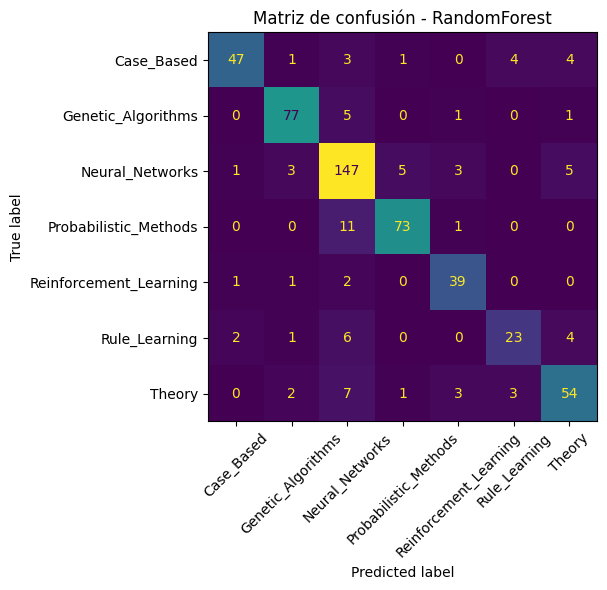

In [11]:
import matplotlib.pyplot as plt

mejor_nombre = resumen_test.iloc[0]["modelo"]
print(f"Mejor modelo en test (según F1 macro): {mejor_nombre}")

print("\nReporte por clase:\n")
print(reportes_clase[mejor_nombre])

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=matrices_confusion[mejor_nombre],
    display_labels=le.classes_, # <--- ¡Aquí está la magia del texto!
).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Matriz de confusión - {mejor_nombre}")
plt.tight_layout()
plt.show()

## 8. Persistencia de artefactos (trazabilidad)

Esta celda permite guardar los artefactos del experimento (métricas, reporte, modelo y metadatos) en una carpeta con timestamp.

- Por defecto esta desactivada (`GUARDAR_ARTEFACTOS = False`).
- Si la activas en `True`, se crea un directorio en `artifacts/tarea_2_1/<timestamp>/` con todo lo necesario para reproducir y auditar el resultado.

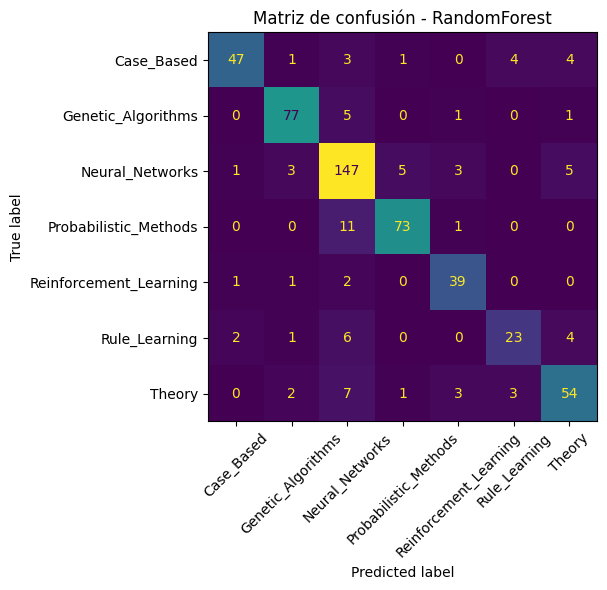

Artefactos guardados en: /mnt/vms/aprendizaje-automatico-relacional/artifacts/tarea_4/20260615_121648
Matriz de confusion guardada en: /mnt/vms/aprendizaje-automatico-relacional/docs/trabajo/figuras/matriz_confusion_RandomForest_20260615_121648.png


In [ ]:
# Persistencia opcional para trazabilidad de experimentos (activar bajo demanda).
from datetime import datetime
import json
from joblib import dump
import matplotlib.pyplot as plt

GUARDAR_ARTEFACTOS = False  # Cambia a True para activar la persistencia de artefactos

if GUARDAR_ARTEFACTOS:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    artifacts_dir = base_dir / "artifacts" / "tarea_4" / timestamp
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    figuras_dir = base_dir / "docs" / "trabajo" / "figuras"
    figuras_dir.mkdir(parents=True, exist_ok=True)

    # Tablas resumen
    resumen_cv.to_csv(artifacts_dir / "resumen_cv.csv", index=False)
    resumen_test.to_csv(artifacts_dir / "resumen_test.csv", index=False)

    # Reporte del mejor modelo
    with open(artifacts_dir / f"reporte_{mejor_nombre}.txt", "w", encoding="utf-8") as f:
        f.write(reportes_clase[mejor_nombre])

    # Serializacion del mejor modelo entrenado
    dump(mejores_modelos[mejor_nombre], artifacts_dir / f"modelo_{mejor_nombre}.joblib")

    # Copia de la matriz de confusion para el informe final
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(
        confusion_matrix=matrices_confusion[mejor_nombre],
        display_labels=le.classes_, # <--- ¡Aquí está la magia del texto!
    ).plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"Matriz de confusión - {mejor_nombre}")
    plt.tight_layout()
    plt.show()

    ruta_figura = figuras_dir / f"matriz_confusion_{mejor_nombre}_{timestamp}.png"
    fig.savefig(ruta_figura, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Metadatos minimos para auditoria
    metadata = {
        "timestamp": timestamp,
        "dataset_fuente": fuente_datos,
        "random_state": RANDOM_STATE,
        "modelo_ganador": mejor_nombre,
        "ruta_figura_confusion": str(ruta_figura),
        "metricas_modelo_ganador": (
            resumen_test.loc[resumen_test["modelo"] == mejor_nombre]
            .iloc[0]
            .to_dict()
        ),
    }

    with open(artifacts_dir / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print(f"Artefactos guardados en: {artifacts_dir}")
    print(f"Matriz de confusion guardada en: {ruta_figura}")
else:
    print("Persistencia desactivada. Cambia GUARDAR_ARTEFACTOS=True para guardar artefactos.")

## 9. Conclusiones y siguientes pasos

<div class="alert alert-success" role="alert">

<h3>Conclusiones</h3>

**Eficacia del Enfoque Heterogéneo:** La combinación quirúrgica de la Bolsa de Palabras (información nativa) con las métricas de centralidad y la pertenencia a comunidades de Louvain (información estructural del grafo) ha demostrado ser sumamente efectiva. El procesamiento diferenciado mediante ColumnTransformer garantizó que cada tipo de dato mantuviera su propiedades estadísticas y geométricas nativas, optimizando la convergencia de los modelos sensibles a la escala.

**Superioridad de los Modelos Complejos:** El ajuste de hiperparámetros mediante validación cruzada estratificada determinó que el Perceptrón Multicapa (MLP) y el *Random Forest* obtienen los rendimientos más robustos, alcanzando un **F1-score macro de ~0.81** en el conjunto de validación. Esto confirma que las relaciones espaciales complejas derivadas de la topología de la red requieren de fronteras de decisión no lineales y ensamblados robustos para ser explotadas al máximo, en contraste con el rendimiento subóptimo de algoritmos como kNN, penalizado por la alta dimensionalidad del texto.

**Rigurosidad ante el Desbalanceo:** El uso estricto del criterio de optimización **F1-macro** obligó a los algoritmos a ponderar por igual el rendimiento en clases minoritarias (como *Rule_Learning*) y mayoritarias (*Neural_Networks*). La matriz de confusión final convalida que los modelos base han adquirido una alta capacidad de generalización fuera de la muestra, sin presentar sesgos críticos hacia la clase dominante.

<h3>Siguientes Pasos (Hacia el Aprendizaje Automático Relacional Puro)</h3>

Aunque el uso de variables topológicas calculadas manualmente (*Handcrafted Graph Features*) ha proporcionado una línea base (*baseline*) sumamente competitiva, este enfoque presenta limitaciones intrínsecas: solo captura propiedades locales (grados) o sectorizadas (comunidades), ignorando la continuidad estructural global de la red de citaciones.

Por tanto, las siguientes fases de la investigación se articularán en torno a la integración de técnicas de aprendizaje de representaciones de grafos (*Graph Representation Learning*), que permitan capturar la topología global y las relaciones complejas entre nodos de manera más efectiva y automatizada.

